# 6. The paper's 6-DOF system under many configurations

`06_paper_six_dof.yaml` holds the baseline of the paper's second script: three 2-DOF
subsystems, all UKF, Jacobi messages, the El Centro record scaled as a force on
mass 4, eight unknowns. Each variant below copies that configuration and overrides a
few keys: the schedule, the filters, the number of inner iterations, the integrator,
or the decomposition itself.

The paper runs 50 s. Set `PCI_T` to change the horizon (this notebook uses 20 s so
that it executes in a couple of minutes).

In [1]:
import copy
import os

import numpy as np

import pci

BASE = pci.load_config("06_paper_six_dof.yaml")
BASE["time"]["T"] = float(os.environ.get("PCI_T", 20.0))
TRUE = {"k3": 45_000.0, "c3": 320.0, "m3": 600.0, "k6": 55_000.0, "c6": 700.0, "k34": 40_000.0, "k9": 40_000.0, "c9": 480.0}
print(open("06_paper_six_dof.yaml").read())

# Baseline of 06_paper_six_dof_configurations.py: the paper's 6-DOF system, all UKF, Jacobi,
# El Centro force on mass 4. The script loads this file and overrides keys for each variant.
model: mass_spring_chain
masses: [500, 500, 600, 500, 500, 500]
springs:
  - {a: ground, b: 1, k: 50000, c: 300}
  - {a: ground, b: 2, k: 40000, c: 350}
  - {a: 1, b: 2, k: 45000, c: 320}
  - {a: 2, b: 3, k: 30000, c: 400}
  - {a: 3, b: 4, k: 25000, c: 480}
  - {a: ground, b: 4, k: 55000, c: 700}
  - {a: 4, b: 5, k: 30000, c: 350}
  - {a: ground, b: 5, k: 45000, c: 460}
  - {a: 5, b: 6, k: 40000, c: 480}
  - {a: 3, b: 4, k: 40000, c: 0, name: "34"}
subsystems: [[1, 2], [3, 4], [5, 6]]
filters: ukf
integrator: heun
schedule: {type: jacobi, iterations: 1}
unknowns:
  k3:  {initial: 31500, std: 1.0e4}
  c3:  {initial: 224,   std: 316}
  m3:  {initial: 570,   std: 100}
  k6:  {initial: 38500, std: 1.0e4}
  c6:  {initial: 490,   std: 31.6}
  k34: {initial: 28000, std: 1.0e4}
  k9:  {initial: 28000, std: 1.0e

## A helper that runs one variant

In [2]:
def run(label, **overrides):
    cfg = copy.deepcopy(BASE)
    for key, val in overrides.items():
        cfg[key] = val
    try:
        res = pci.solve(cfg)
    except (NotImplementedError, RuntimeError) as exc:
        print(f"{label:<44s} FAILED: {str(exc)[:90]}")
        return None
    T = cfg["time"]["T"]
    errs = {p: 100.0 * (res.final(p) - TRUE[p]) / TRUE[p] for p in cfg["unknowns"]}
    x_rmse = np.mean([res.rmse([f"x{d}"], start=T / 2)[f"x{d}"] for d in range(1, 7)])
    worst = max(errs, key=lambda p: abs(errs[p]))
    print(f"{label:<44s} {res.runtime:6.1f}s  mean x-RMSE {x_rmse:.2e}  max |param err| {abs(errs[worst]):5.2f}% ({worst})  "
          + "  ".join(f"{p}={errs[p]:+.1f}%" for p in errs))
    return res

## Schedules, filters, integrators

In [3]:
print(f"6-DOF paper system, T = {BASE['time']['T']} s, dt = {BASE['time']['dt']}\n")
print(f"{'configuration':<44s} {'time':>7s}")
baseline = run("paper baseline: 3x2-DOF, UKF, Jacobi")
run("3x2-DOF, UKF, Gauss-Seidel", schedule="gauss_seidel")
run("3x2-DOF, UKF, AB2", schedule="ab2")
run("3x2-DOF, UKF, Jacobi x2 inner iterations", schedule={"type": "jacobi", "iterations": 2})
run("3x2-DOF, CKF, Jacobi", filters="ckf")
run("3x2-DOF, EKF, Jacobi", filters="ekf")
run("3x2-DOF, mixed UKF/CKF/EKF, Jacobi", filters={"S1": "ukf", "S2": "ckf", "S3": "ekf"})
run("3x2-DOF, UKF, Jacobi, Euler integrator", integrator="euler")
run("3x2-DOF, UKF, Jacobi, RK4 integrator", integrator="rk4");

6-DOF paper system, T = 20.0 s, dt = 0.002

configuration                                   time


paper baseline: 3x2-DOF, UKF, Jacobi            5.6s  mean x-RMSE 7.89e-05  max |param err|  6.14% (c9)  k3=-0.3%  c3=+4.6%  m3=+0.1%  k6=-0.0%  c6=+5.7%  k34=-0.4%  k9=+0.4%  c9=+6.1%


3x2-DOF, UKF, Gauss-Seidel                      5.6s  mean x-RMSE 1.44e-04  max |param err|  7.88% (c6)  k3=-0.1%  c3=+5.1%  m3=+0.5%  k6=+0.4%  c6=+7.9%  k34=-0.1%  k9=-0.3%  c9=+2.4%


3x2-DOF, UKF, AB2                               5.7s  mean x-RMSE 5.67e-05  max |param err|  2.65% (c9)  k3=-0.3%  c3=+0.0%  m3=+0.0%  k6=+0.4%  c6=+1.2%  k34=-0.1%  k9=+0.1%  c9=+2.6%


3x2-DOF, UKF, Jacobi x2 inner iterations       10.9s  mean x-RMSE 4.92e-05  max |param err|  1.77% (c3)  k3=-0.1%  c3=+1.8%  m3=+0.0%  k6=+0.3%  c6=+0.6%  k34=+0.0%  k9=+0.2%  c9=+1.8%


3x2-DOF, CKF, Jacobi                            5.3s  mean x-RMSE 7.89e-05  max |param err|  6.14% (c9)  k3=-0.3%  c3=+4.6%  m3=+0.1%  k6=-0.0%  c6=+5.7%  k34=-0.4%  k9=+0.4%  c9=+6.1%


3x2-DOF, EKF, Jacobi                            5.9s  mean x-RMSE 8.17e-05  max |param err|  6.27% (c9)  k3=-0.3%  c3=+4.5%  m3=+0.1%  k6=-0.0%  c6=+5.9%  k34=-0.4%  k9=+0.4%  c9=+6.3%


3x2-DOF, mixed UKF/CKF/EKF, Jacobi              5.8s  mean x-RMSE 8.18e-05  max |param err|  6.30% (c9)  k3=-0.3%  c3=+4.4%  m3=+0.1%  k6=-0.1%  c6=+5.9%  k34=-0.4%  k9=+0.4%  c9=+6.3%


3x2-DOF, UKF, Jacobi, Euler integrator          4.3s  mean x-RMSE 1.51e-04  max |param err|  3.53% (c3)  k3=-0.1%  c3=+3.5%  m3=-0.2%  k6=+0.7%  c6=+0.4%  k34=-0.2%  k9=+0.3%  c9=+2.8%


3x2-DOF, UKF, Jacobi, RK4 integrator            8.4s  mean x-RMSE 7.88e-05  max |param err|  6.16% (c9)  k3=-0.3%  c3=+4.5%  m3=+0.1%  k6=-0.0%  c6=+5.6%  k34=-0.4%  k9=+0.4%  c9=+6.2%


## Other decompositions of the same physical system

Unknowns must stay internal to a subsystem, so each partition drops the unknowns
that would sit on an interface spring.

In [4]:
unk = BASE["unknowns"]
run("2 subsystems [1,2,3],[4,5,6], UKF", subsystems=[[1, 2, 3], [4, 5, 6]],
    unknowns={k: v for k, v in unk.items() if k not in ("k34", "k6", "c6")})
run("uneven [1],[2,3],[4,5,6], UKF, Gauss-Seidel", subsystems=[[1], [2, 3], [4, 5, 6]], schedule="gauss_seidel",
    sensors=["a1", "a2", "a3", "a4", "a5", "a6"],
    noise_std={"a1": 3e-2, "a2": 3e-2, "a3": 1e-1, "a4": 1e-1, "a5": 3e-2, "a6": 3e-2},
    unknowns={k: v for k, v in unk.items() if k not in ("k3", "c3", "k34", "m3")})
run("monolithic (1 subsystem), UKF", subsystems=[[1, 2, 3, 4, 5, 6]]);

2 subsystems [1,2,3],[4,5,6], UKF               5.2s  mean x-RMSE 1.26e-04  max |param err|  5.11% (c3)  k3=+0.0%  c3=+5.1%  m3=+0.5%  k9=-0.3%  c9=+1.7%


uneven [1],[2,3],[4,5,6], UKF, Gauss-Seidel     5.1s  mean x-RMSE 3.20e-04  max |param err|  5.76% (c6)  k6=+1.4%  c6=+5.8%  k9=-0.7%  c9=-3.0%


monolithic (1 subsystem), UKF                   9.0s  mean x-RMSE 1.22e-05  max |param err|  0.74% (c3)  k3=-0.0%  c3=+0.7%  m3=-0.0%  k6=-0.2%  c6=-0.2%  k34=+0.1%  k9=-0.0%  c9=+0.0%


## The baseline's parameter trajectories

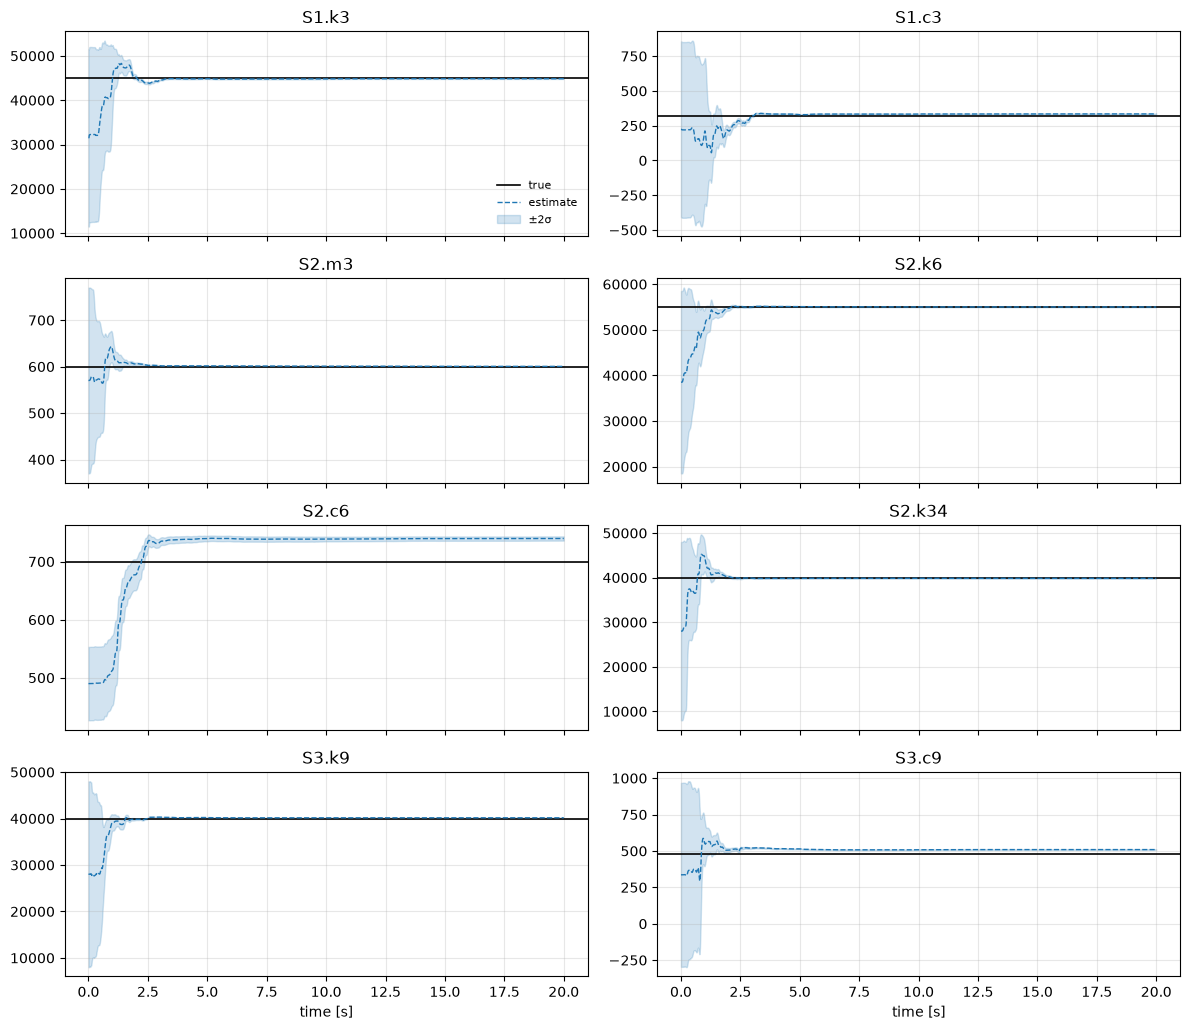

In [5]:
baseline.plot_parameters();